<a href="https://colab.research.google.com/github/Chethana1705/Bitcoin-Price-Prediction/blob/main/sp(model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Setup and Installation
from google.colab import drive
drive.mount('/content/drive')

# Navigate to working directory
%cd /content

# Install all required packages
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install pytorchvideo opencv-python-headless mediapipe pandas scikit-learn tqdm matplotlib

print("✅ All packages installed successfully!")

Mounted at /content/drive
/content
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 26.3 MB/s eta 0:00:00
  Created wheel for pytorchvideo: filename=pytorchvideo-0.1.5-py3-none-any.whl size=188686 sha256=e55da0aa0e4f2d9ab44a91355ac3148801e9ca19571e6cc665e3e70124d

✅ All packages installed successfully!


In [ ]:
# Cell 2: Create project structure
!mkdir -p /content/src
!mkdir -p /content/data/processed/clips
!mkdir -p /content/weights

print("Project structure created:")
!find /content -type d -name "src" -o -name "data" -o -name "weights"

Project structure created:
/content/weights
/content/drive/MyDrive/Colab Notebooks/deepfake_project/src
/content/drive/.Encrypted/MyDrive/Colab Notebooks/deepfake_project/src
/content/src
/content/data


In [ ]:
# Cell 3: Upload your files
from google.colab import files
import os

print("📁 Step 1: Upload your Python files")
print("Please upload these files one by one:")
print("1. preprocess.py")
print("2. model.py")
print("3. train.py")
print("4. inference.py (if you have it)")

# Upload the files
uploaded = files.upload()

# Move them to the right folder
for filename in uploaded.keys():
    !mv "{filename}" "/content/src/"
    print(f"✅ Moved {filename} to /content/src/")

print("\n📊 Step 2: Upload your data files")
print("Upload labels.csv and any clip files if you have them")
uploaded_data = files.upload()
for filename in uploaded_data.keys():
    if filename.endswith('.csv'):
        !mv "{filename}" "/content/data/"
    else:
        !mv "{filename}" "/content/data/processed/clips/"
    print(f"✅ Moved {filename} to data directory")

print("\n✅ All files uploaded!")

📁 Step 1: Upload your Python files
Please upload these files one by one:
1. preprocess.py
2. model.py
3. train.py
4. inference.py (if you have it)


Saving inference.py to inference.py
Saving train.py to train.py
Saving model.py to model.py
Saving preprocess.py to preprocess.py
✅ Moved inference.py to /content/src/
✅ Moved train.py to /content/src/
✅ Moved model.py to /content/src/
✅ Moved preprocess.py to /content/src/

📊 Step 2: Upload your data files
Upload labels.csv and any clip files if you have them


Saving labels.csv to labels.csv
✅ Moved labels.csv to data directory

✅ All files uploaded!


In [ ]:
# Cell 4: Verify files
print("📁 Contents of /content/src/:")
!ls -la /content/src/

print("\n📊 Contents of /content/data/:")
!ls -la /content/data/

print("\n🎬 Contents of clips folder (if any):")
!ls -la /content/data/processed/clips/ | head -5

📁 Contents of /content/src/:
total 28
drwxr-xr-x 2 root root 4096 Sep 12 09:32 .
drwxr-xr-x 1 root root 4096 Sep 12 09:34 ..
-rw-r--r-- 1 root root 2122 Sep 12 09:32 inference.py
-rw-r--r-- 1 root root  777 Sep 12 09:32 model.py
-rw-r--r-- 1 root root 3691 Sep 12 09:32 preprocess.py
-rw-r--r-- 1 root root 4620 Sep 12 09:32 train.py

📊 Contents of /content/data/:
total 16
drwxr-xr-x 3 root root 4096 Sep 12 09:34 .
drwxr-xr-x 1 root root 4096 Sep 12 09:34 ..
-rw-r--r-- 1 root root   53 Sep 12 09:34 labels.csv
drwxr-xr-x 3 root root 4096 Sep 12 09:20 processed

🎬 Contents of clips folder (if any):
total 16
drwxr-xr-x 2 root root 4096 Sep 12 09:30 .
drwxr-xr-x 3 root root 4096 Sep 12 09:20 ..
-rw-r--r-- 1 root root 4620 Sep 12 09:30 train.py


In [ ]:
# Cell 5: Test GPU
import torch
import pandas as pd

print("🚀 GPU Status:")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print("\n📦 Checking imports:")
try:
    import cv2, mediapipe, pytorchvideo
    print("✅ All packages imported successfully!")
except Exception as e:
    print(f"❌ Error: {e}")

print("\n🐍 Python version:")
!python --version

🚀 GPU Status:
GPU available: True
GPU name: Tesla T4
GPU memory: 14.7 GB

📦 Checking imports:
✅ All packages imported successfully!

🐍 Python version:
Python 3.12.11


In [ ]:
# Cell 6: Run training
print("🏃 Starting training...")
!python /content/src/train.py

print("\n✅ Training completed!")

🏃 Starting training...
Using device: cuda
GPU: Tesla T4
Traceback (most recent call last):
  File "/content/src/train.py", line 133, in <module>
    main()
  File "/content/src/train.py", line 67, in main
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py", line 2872, in train_test_split
    train, test = next(cv.split(X=arrays[0], y=stratify))
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py", line 1909, in split
    for train, test in self._iter_indices(X, y, groups):
                       ^^^^^^^^^^^^

In [ ]:
# Cell 7: Save to Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Create a backup folder in Drive
!mkdir -p "/content/drive/MyDrive/Deepfake_Project_Backup"

# Copy your trained model and results
!cp -r /content/weights "/content/drive/MyDrive/Deepfake_Project_Backup/"
!cp -r /content/src "/content/drive/MyDrive/Deepfake_Project_Backup/"

print("✅ All files saved to Google Drive!")
print("You can find them in: My Drive > Deepfake_Project_Backup")

Mounted at /content/drive
✅ All files saved to Google Drive!
You can find them in: My Drive > Deepfake_Project_Backup


In [ ]:
# Create a simple test video with OpenCV (run this in a new cell)
import cv2
import numpy as np

# Create a sample red video (fake)
height, width = 128, 128
out = cv2.VideoWriter('/content/test_fake.avi', cv2.VideoWriter_fourcc(*'XVID'), 10, (width, height))
for _ in range(30):
    frame = np.zeros((height, width, 3), dtype=np.uint8)
    frame[:, :] = [0, 0, 255]  # Red frame
    out.write(frame)
out.release()

# Create a sample blue video (real)
out = cv2.VideoWriter('/content/test_real.avi', cv2.VideoWriter_fourcc(*'XVID'), 10, (width, height))
for _ in range(30):
    frame = np.zeros((height, width, 3), dtype=np.uint8)
    frame[:, :] = [255, 0, 0]  # Blue frame
    out.write(frame)
out.release()

print("Created sample test videos!")

Created sample test videos!


In [ ]:
# Create a simple CSV for testing
import pandas as pd

test_data = [
    {'clip_path': '/content/test_fake.avi', 'label': 1},
    {'clip_path': '/content/test_real.avi', 'label': 0}
]

df = pd.DataFrame(test_data)
df.to_csv('/content/data/labels.csv', index=False)
print("Created test labels.csv")

Created test labels.csv


In [ ]:
# Create a proper test dataset with multiple samples
import pandas as pd
import numpy as np
import os

# Create multiple test samples
test_data = []
for i in range(10):  # Create 10 fake samples
    test_data.append({'clip_path': f'/content/test_fake_{i}.avi', 'label': 1})
for i in range(10):  # Create 10 real samples
    test_data.append({'clip_path': f'/content/test_real_{i}.avi', 'label': 0})

# Create the CSV
df = pd.DataFrame(test_data)
df.to_csv('/content/data/labels.csv', index=False)
print("Created test dataset with 20 samples (10 real, 10 fake)")
print(df.head())

Created test dataset with 20 samples (10 real, 10 fake)
                  clip_path  label
0  /content/test_fake_0.avi      1
1  /content/test_fake_1.avi      1
2  /content/test_fake_2.avi      1
3  /content/test_fake_3.avi      1
4  /content/test_fake_4.avi      1


In [ ]:
# Create the actual video files for testing
import cv2
import numpy as np

# Create directory for test videos
!mkdir -p /content/test_videos

# Create multiple sample videos
for i in range(10):  # Fake videos (red)
    height, width = 128, 128
    out = cv2.VideoWriter(f'/content/test_fake_{i}.avi', cv2.VideoWriter_fourcc(*'XVID'), 10, (width, height))
    for _ in range(16):  # 16 frames per clip
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        frame[:, :] = [0, 0, 255]  # Red = fake
        out.write(frame)
    out.release()

for i in range(10):  # Real videos (blue)
    height, width = 128, 128
    out = cv2.VideoWriter(f'/content/test_real_{i}.avi', cv2.VideoWriter_fourcc(*'XVID'), 10, (width, height))
    for _ in range(16):  # 16 frames per clip
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        frame[:, :] = [255, 0, 0]  # Blue = real
        out.release()

print("Created 20 sample video files")

Created 20 sample video files


In [ ]:
# Check your dataset
import pandas as pd

df = pd.read_csv('/content/data/labels.csv')
print("Dataset info:")
print(f"Total samples: {len(df)}")
print(f"Real samples (0): {len(df[df['label'] == 0])}")
print(f"Fake samples (1): {len(df[df['label'] == 1])}")

print("\nFirst few rows:")
print(df.head())

Dataset info:
Total samples: 20
Real samples (0): 10
Fake samples (1): 10

First few rows:
                  clip_path  label
0  /content/test_fake_0.avi      1
1  /content/test_fake_1.avi      1
2  /content/test_fake_2.avi      1
3  /content/test_fake_3.avi      1
4  /content/test_fake_4.avi      1


In [ ]:
# Debug your dataset
import pandas as pd
import cv2

df = pd.read_csv('/content/data/labels.csv')
print(f"Total samples in CSV: {len(df)}")

# Check a few video files to see if they can be read
for i, row in df.head(3).iterrows():
    clip_path = row['clip_path']
    print(f"\nChecking: {clip_path}")

    cap = cv2.VideoCapture(clip_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    cap.release()
    print(f"Frames read: {len(frames)}")

    if len(frames) == 0:
        print(f"❌ ERROR: Could not read any frames from {clip_path}")
    else:
        print(f"✅ OK: Successfully read {len(frames)} frames")

Total samples in CSV: 20

Checking: /content/test_fake_0.avi
Frames read: 16
✅ OK: Successfully read 16 frames

Checking: /content/test_fake_1.avi
Frames read: 16
✅ OK: Successfully read 16 frames

Checking: /content/test_fake_2.avi
Frames read: 16
✅ OK: Successfully read 16 frames


In [ ]:
# Create a backup first
!cp /content/src/train.py /content/src/train.py.backup

# Update the dataset class to handle bad files
with open('/content/src/train.py', 'w') as f:
    f.write('''
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import pandas as pd
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from model import get_model
import os
import random

# 1. Create a Custom Dataset Class
class DeepfakeDataset(Dataset):
    def __init__(self, data_frame, transform=None):
        self.data = data_frame
        self.transform = transform
        # Filter out files that don't exist or are empty
        self.valid_indices = []
        for idx in range(len(self.data)):
            clip_path = self.data.iloc[idx]['clip_path']
            if os.path.exists(clip_path):
                cap = cv2.VideoCapture(clip_path)
                ret, frame = cap.read()
                cap.release()
                if ret:
                    self.valid_indices.append(idx)
        print(f"Found {len(self.valid_indices)} valid videos out of {len(self.data)}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        row = self.data.iloc[actual_idx]
        clip_path = row['clip_path']
        label = row['label']

        # Read the video clip with error handling
        cap = cv2.VideoCapture(clip_path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()

        # If no frames were read, create a dummy frame
        if len(frames) == 0:
            print(f"Warning: No frames read from {clip_path}, using dummy data")
            frames = [np.zeros((128, 128, 3), dtype=np.uint8) for _ in range(16)]

        video = np.stack(frames) # Shape: [T, H, W, C]

        if self.transform:
            video = torch.stack([self.transform(f) for f in video]) # Apply transform to each frame
        # PyTorchVideo needs [C, T, H, W]
        video = video.permute(3, 0, 1, 2)

        return video, torch.tensor(label, dtype=torch.long)

# 2. Define Transforms
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 3. Main Training Function
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    if device.type == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")

    # Load data
    df = pd.read_csv('data/labels.csv')
    print(f"Total samples in CSV: {len(df)}")

    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

    train_dataset = DeepfakeDataset(data_frame=train_df, transform=train_transform)
    val_dataset = DeepfakeDataset(data_frame=val_df, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)  # Reduced batch size and workers
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

    # Initialize model, loss, optimizer
    model = get_model(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

    # Create weights directory
    os.makedirs('weights', exist_ok=True)

    # Training loop
    num_epochs = 3  # Reduced for testing
    best_acc = 0.0

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        for videos, labels in train_loader:
            videos, labels = videos.to(device).float(), labels.to(device)
            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for videos, labels in val_loader:
                videos, labels = videos.to(device).float(), labels.to(device)
                outputs = model(videos)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}%")

        # Save the best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'weights/best_model.pth')
            print(f"Saved new best model with accuracy: {best_acc:.2f}%")

    print(f"Training finished. Best validation accuracy: {best_acc:.2f}%")

if __name__ == "__main__":
    main()
''')

print("Updated train.py with better error handling!")

Updated train.py with better error handling!


In [ ]:
# Create proper test videos that will definitely work
import cv2
import numpy as np

# Create 10 real and 10 fake videos
for i in range(20):
    label = 1 if i < 10 else 0  # First 10 are fake, next 10 are real
    color = [0, 0, 255] if label == 1 else [255, 0, 0]  # Red for fake, Blue for real

    filename = f'/content/test_{"fake" if label == 1 else "real"}_{i}.avi'
    height, width = 128, 128
    out = cv2.VideoWriter(filename, cv2.VideoWriter_fourcc(*'XVID'), 10, (width, height))

    # Create 16 frames with slight variations
    for j in range(16):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        frame[:, :] = color
        # Add some variation so frames aren't identical
        cv2.putText(frame, f"Frame {j}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        out.write(frame)

    out.release()

print("Created 20 proper test videos!")

Created 20 proper test videos!


In [ ]:
# Create a new CSV with the proper videos
import pandas as pd

test_data = []
for i in range(10):  # 10 fake videos
    test_data.append({'clip_path': f'/content/test_fake_{i}.avi', 'label': 1})
for i in range(10):  # 10 real videos
    test_data.append({'clip_path': f'/content/test_real_{i}.avi', 'label': 0})

df = pd.DataFrame(test_data)
df.to_csv('/content/data/labels.csv', index=False)
print("Created new labels.csv with proper video paths")
print(df.head())

Created new labels.csv with proper video paths
                  clip_path  label
0  /content/test_fake_0.avi      1
1  /content/test_fake_1.avi      1
2  /content/test_fake_2.avi      1
3  /content/test_fake_3.avi      1
4  /content/test_fake_4.avi      1


In [ ]:
# Create a backup first
!cp /content/src/train.py /content/src/train.py.backup2

# Fix the dimension issue in train.py
with open('/content/src/train.py', 'w') as f:
    f.write('''
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import pandas as pd
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from model import get_model
import os
import random

# 1. Create a Custom Dataset Class
class DeepfakeDataset(Dataset):
    def __init__(self, data_frame, transform=None):
        self.data = data_frame
        self.transform = transform
        # Filter out files that don't exist or are empty
        self.valid_indices = []
        for idx in range(len(self.data)):
            clip_path = self.data.iloc[idx]['clip_path']
            if os.path.exists(clip_path):
                cap = cv2.VideoCapture(clip_path)
                ret, frame = cap.read()
                cap.release()
                if ret:
                    self.valid_indices.append(idx)
        print(f"Found {len(self.valid_indices)} valid videos out of {len(self.data)}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        row = self.data.iloc[actual_idx]
        clip_path = row['clip_path']
        label = row['label']

        # Read the video clip with error handling
        cap = cv2.VideoCapture(clip_path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()

        # If no frames were read, create a dummy frame
        if len(frames) == 0:
            print(f"Warning: No frames read from {clip_path}, using dummy data")
            frames = [np.zeros((128, 128, 3), dtype=np.uint8) for _ in range(16)]

        # Ensure we have exactly 16 frames (pad or truncate if needed)
        if len(frames) > 16:
            frames = frames[:16]  # Truncate to 16 frames
        elif len(frames) < 16:
            # Pad with last frame if we don't have enough
            frames.extend([frames[-1]] * (16 - len(frames)))

        video = np.stack(frames)  # Shape: [T, H, W, C] = [16, 128, 128, 3]

        if self.transform:
            # Apply transform to each frame individually
            transformed_frames = []
            for frame in video:
                frame_pil = transforms.ToPILImage()(frame)
                frame_tensor = self.transform(frame_pil)
                transformed_frames.append(frame_tensor)
            video = torch.stack(transformed_frames)  # Shape: [T, C, H, W] = [16, 3, 128, 128]
        else:
            # Convert to tensor without additional transforms
            video = torch.from_numpy(video).float()  # Shape: [T, H, W, C]
            video = video.permute(0, 3, 1, 2)  # Shape: [T, C, H, W] = [16, 3, 128, 128]

        # PyTorchVideo needs [C, T, H, W] = [3, 16, 128, 128]
        video = video.permute(1, 0, 2, 3)  # From [T, C, H, W] to [C, T, H, W]

        return video, torch.tensor(label, dtype=torch.long)

# 2. Define Transforms
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 3. Main Training Function
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    if device.type == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")

    # Load data
    df = pd.read_csv('data/labels.csv')
    print(f"Total samples in CSV: {len(df)}")

    # For very small datasets, don't use stratification
    if len(df) < 4:
        train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
    else:
        train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    train_dataset = DeepfakeDataset(data_frame=train_df, transform=train_transform)
    val_dataset = DeepfakeDataset(data_frame=val_df, transform=val_transform)

    # Use smaller batch size for small datasets
    batch_size = min(2, len(train_dataset))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # Initialize model, loss, optimizer
    model = get_model(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

    # Create weights directory
    os.makedirs('weights', exist_ok=True)

    # Training loop
    num_epochs = 3  # Reduced for testing
    best_acc = 0.0

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        for videos, labels in train_loader:
            videos, labels = videos.to(device).float(), labels.to(device)

            # Debug: print input shape
            if epoch == 0 and running_loss == 0:
                print(f"Input shape: {videos.shape}")  # Should be [batch, 3, 16, 128, 128]

            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for videos, labels in val_loader:
                videos, labels = videos.to(device).float(), labels.to(device)
                outputs = model(videos)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader) if len(train_loader) > 0 else 0
        val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
        val_acc = 100 * correct / total if total > 0 else 0

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}%")

        # Save the best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'weights/best_model.pth')
            print(f"Saved new best model with accuracy: {best_acc:.2f}%")

    print(f"Training finished. Best validation accuracy: {best_acc:.2f}%")

if __name__ == "__main__":
    main()
''')

print("Fixed the dimension issue in train.py!")

Fixed the dimension issue in train.py!


In [ ]:
# Let's verify our test videos are correct
import cv2
import numpy as np

# Check one of the test videos
cap = cv2.VideoCapture('/content/test_fake_0.avi')
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)
cap.release()

print(f"Frames in test video: {len(frames)}")
if len(frames) > 0:
    print(f"Frame shape: {frames[0].shape}")  # Should be (128, 128, 3)
    print(f"Frame type: {type(frames[0])}")
    print(f"Frame dtype: {frames[0].dtype}")

Frames in test video: 16
Frame shape: (128, 128, 3)
Frame type: <class 'numpy.ndarray'>
Frame dtype: uint8


In [ ]:
# Update the dataset to use 64x64 instead of 128x128
!sed -i 's/128, 128/64, 64/g' /content/src/train.py
!sed -i 's/Resize((128, 128))/Resize((64, 64))/g' /content/src/train.py

print("Changed input size from 128x128 to 64x64")

Changed input size from 128x128 to 64x64


In [ ]:
# Update train.py to use the simple model
with open('/content/src/train.py', 'r') as f:
    content = f.read()

# Replace the model import and initialization
content = content.replace(
    'from model import get_model',
    'from model import SimpleDeepfakeDetector, get_model'
)
content = content.replace(
    '    model = get_model(device)',
    '    model = SimpleDeepfakeDetector(num_classes=2).to(device)'
)

with open('/content/src/train.py', 'w') as f:
    f.write(content)

print("Updated train.py to use the simple model!")

Updated train.py to use the simple model!


In [ ]:
# Check what's in your data folder
import pandas as pd
import os

print("Contents of data directory:")
!ls -la /content/data/

print("\nContents of processed clips:")
!ls -la /content/data/processed/clips/ 2>/dev/null || echo "No clips directory found"

print("\nCurrent labels.csv:")
try:
    df = pd.read_csv('/content/data/labels.csv')
    print(f"Labels shape: {df.shape}")
    print(df.head())
except:
    print("No labels.csv found or error reading it")

Contents of data directory:
total 16
drwxr-xr-x 3 root root 4096 Sep 12 09:34 .
drwxr-xr-x 1 root root 4096 Sep 12 09:49 ..
-rw-r--r-- 1 root root   70 Sep 12 09:50 labels.csv
drwxr-xr-x 3 root root 4096 Sep 12 09:20 processed

Contents of processed clips:
total 16
drwxr-xr-x 2 root root 4096 Sep 12 09:30 .
drwxr-xr-x 3 root root 4096 Sep 12 09:20 ..
-rw-r--r-- 1 root root 4620 Sep 12 09:30 train.py

Current labels.csv:
Labels shape: (2, 2)
                  clip_path  label
0  /content/test_fake_0.avi      1
1  /content/test_real_0.avi      0


In [ ]:
# Run the training with your data
!python /content/src/train.py

Using device: cuda
GPU: Tesla T4
Total samples in CSV: 2
Found 1 valid videos out of 1
Found 0 valid videos out of 1
Input shape: torch.Size([1, 3, 16, 64, 64])
Epoch [1/3] | Train Loss: 0.4170 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch [2/3] | Train Loss: 0.7047 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch [3/3] | Train Loss: 0.4560 | Val Loss: 0.0000 | Val Acc: 0.00%
Training finished. Best validation accuracy: 0.00%


In [ ]:
# Create more test videos
import cv2
import numpy as np

# Create 10 fake and 10 real videos
for i in range(20):
    label = 1 if i < 10 else 0  # First 10 fake, next 10 real
    color = [0, 0, 255] if label == 1 else [255, 0, 0]  # Red fake, Blue real

    filename = f'/content/test_{"fake" if label == 1 else "real"}_{i}.avi'
    height, width = 64, 64
    out = cv2.VideoWriter(filename, cv2.VideoWriter_fourcc(*'XVID'), 10, (width, height))

    # Create 16 frames with slight variations
    for j in range(16):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        frame[:, :] = color
        # Add some variation so frames aren't identical
        cv2.putText(frame, f"F{label}_{i}_{j}", (5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 255, 255), 1)
        out.write(frame)

    out.release()

print("Created 20 test videos (10 fake, 10 real)")

Created 20 test videos (10 fake, 10 real)


In [ ]:
# Create a new CSV with all videos
import pandas as pd

test_data = []
for i in range(10):  # 10 fake videos
    test_data.append({'clip_path': f'/content/test_fake_{i}.avi', 'label': 1})
for i in range(10):  # 10 real videos
    test_data.append({'clip_path': f'/content/test_real_{i}.avi', 'label': 0})

df = pd.DataFrame(test_data)
df.to_csv('/content/data/labels.csv', index=False)
print("Created new labels.csv with 20 samples")
print(f"Real: {len(df[df['label'] == 0])}, Fake: {len(df[df['label'] == 1])}")

Created new labels.csv with 20 samples
Real: 10, Fake: 10


In [ ]:
# Update training parameters for better results
with open('/content/src/train.py', 'r') as f:
    content = f.read()

# Increase epochs and adjust learning rate
content = content.replace('num_epochs = 3', 'num_epochs = 10')
content = content.replace('lr=0.0001', 'lr=0.0003')

with open('/content/src/train.py', 'w') as f:
    f.write(content)

print("Updated training parameters!")

Updated training parameters!


In [ ]:
# Now run training with the larger dataset
!python /content/src/train.py

Using device: cuda
GPU: Tesla T4
Total samples in CSV: 20
Found 8 valid videos out of 16
Found 2 valid videos out of 4
Input shape: torch.Size([2, 3, 16, 64, 64])
Epoch [1/10] | Train Loss: 0.3321 | Val Loss: 0.6769 | Val Acc: 100.00%
Saved new best model with accuracy: 100.00%
Epoch [2/10] | Train Loss: 0.1319 | Val Loss: 0.6333 | Val Acc: 100.00%
Epoch [3/10] | Train Loss: 0.1082 | Val Loss: 0.5147 | Val Acc: 100.00%
Epoch [4/10] | Train Loss: 0.0303 | Val Loss: 0.3419 | Val Acc: 100.00%
Epoch [5/10] | Train Loss: 0.0484 | Val Loss: 0.1742 | Val Acc: 100.00%
Epoch [6/10] | Train Loss: 0.0144 | Val Loss: 0.0825 | Val Acc: 100.00%
Epoch [7/10] | Train Loss: 0.0134 | Val Loss: 0.0406 | Val Acc: 100.00%
Epoch [8/10] | Train Loss: 0.0263 | Val Loss: 0.0217 | Val Acc: 100.00%
Epoch [9/10] | Train Loss: 0.0123 | Val Loss: 0.0128 | Val Acc: 100.00%
Epoch [10/10] | Train Loss: 0.0072 | Val Loss: 0.0085 | Val Acc: 100.00%
Training finished. Best validation accuracy: 100.00%


In [ ]:
# Check your training results
import matplotlib.pyplot as plt

# After training, you can analyze results
print("Training completed! Next steps:")
print("1. Your model is learning (loss is decreasing)")
print("2. Now you need more diverse real data")
print("3. Consider using FaceForensics++ dataset for better results")
print("4. The architecture is working - that's the hardest part!")

# Save your successful model
!cp -r /content/weights "/content/drive/MyDrive/Deepfake_Project_Weights"
print("Model weights saved to Google Drive!")

Training completed! Next steps:
1. Your model is learning (loss is decreasing)
2. Now you need more diverse real data
3. Consider using FaceForensics++ dataset for better results
4. The architecture is working - that's the hardest part!
Model weights saved to Google Drive!


In [ ]:
# Completely rewrite the model.py file
with open('/content/src/model.py', 'w') as f:
    f.write('''
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleDeepfakeDetector(nn.Module):
    """
    A simpler 3D CNN model that works with 16x128x128 input
    """
    def __init__(self, num_classes=2):
        super().__init__()

        # Input: [batch, 3, 16, 128, 128]
        self.conv1 = nn.Conv3d(3, 16, kernel_size=(3, 5, 5), stride=(1, 2, 2), padding=(1, 2, 2))
        self.bn1 = nn.BatchNorm3d(16)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))

        # After conv1: [batch, 16, 16, 64, 64]
        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn2 = nn.BatchNorm3d(32)
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool2: [batch, 32, 8, 32, 32]
        self.conv3 = nn.Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn3 = nn.BatchNorm3d(64)
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool3: [batch, 64, 4, 16, 16]
        self.conv4 = nn.Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn4 = nn.BatchNorm3d(128)
        self.pool4 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool4: [batch, 128, 2, 8, 8]
        self.global_pool = nn.AdaptiveAvgPool3d((1, 1, 1))

        # After global pool: [batch, 128, 1, 1, 1]
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Input: [batch, channels, time, height, width]
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

def get_model(device="cuda" if torch.cuda.is_available() else "cpu"):
    model = SimpleDeepfakeDetector(num_classes=2)
    return model.to(device)
''')

print("✅ model.py rewritten with correct SimpleDeepfakeDetector class!")

✅ model.py rewritten with correct SimpleDeepfakeDetector class!


In [ ]:
# Check if the class is now in the file
!grep -n "class SimpleDeepfakeDetector" /content/src/model.py

6:class SimpleDeepfakeDetector(nn.Module):


In [ ]:
# Test the import again
try:
    from src.model import SimpleDeepfakeDetector
    print("✅ SUCCESS: SimpleDeepfakeDetector imported successfully!")

    # Test the model
    device = torch.device('cuda')
    model = SimpleDeepfakeDetector(num_classes=2).to(device)
    print("✅ Model created successfully!")

    # Test forward pass
    dummy_input = torch.randn(1, 3, 16, 128, 128).to(device)
    output = model(dummy_input)
    print(f"✅ Forward pass successful! Input: {dummy_input.shape}, Output: {output.shape}")

except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Let me check what's in the file...")
    !cat /content/src/model.py | head -20

❌ Import error: cannot import name 'SimpleDeepfakeDetector' from 'src.model' (/content/src/model.py)
Let me check what's in the file...

import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleDeepfakeDetector(nn.Module):
    """
    A simpler 3D CNN model that works with 16x128x128 input
    """
    def __init__(self, num_classes=2):
        super().__init__()
        
        # Input: [batch, 3, 16, 128, 128]
        self.conv1 = nn.Conv3d(3, 16, kernel_size=(3, 5, 5), stride=(1, 2, 2), padding=(1, 2, 2))
        self.bn1 = nn.BatchNorm3d(16)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))
        
        # After conv1: [batch, 16, 16, 64, 64]
        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn2 = nn.BatchNorm3d(32)


In [ ]:
# Fix the lowercase 'conv3d' to 'Conv3d'
with open('/content/src/model.py', 'w') as f:
    f.write('''
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleDeepfakeDetector(nn.Module):
    """
    A simpler 3D CNN model that works with 16x128x128 input
    """
    def __init__(self, num_classes=2):
        super().__init__()

        # Input: [batch, 3, 16, 128, 128]
        self.conv1 = nn.Conv3d(3, 16, kernel_size=(3, 5, 5), stride=(1, 2, 2), padding=(1, 2, 2))
        self.bn1 = nn.BatchNorm3d(16)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))

        # After conv1: [batch, 16, 16, 64, 64]
        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn2 = nn.BatchNorm3d(32)
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool2: [batch, 32, 8, 32, 32]
        self.conv3 = nn.Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn3 = nn.BatchNorm3d(64)
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool3: [batch, 64, 4, 16, 16]
        self.conv4 = nn.Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn4 = nn.BatchNorm3d(128)
        self.pool4 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool4: [batch, 128, 2, 8, 8]
        self.global_pool = nn.AdaptiveAvgPool3d((1, 1, 1))

        # After global pool: [batch, 128, 1, 1, 1]
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Input: [batch, channels, time, height, width]
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

def get_model(device="cuda" if torch.cuda.is_available() else "cpu"):
    model = SimpleDeepfakeDetector(num_classes=2)
    return model.to(device)
''')

print("✅ Fixed model.py with correct 'Conv3d' (capital C)!")

✅ Fixed model.py with correct 'Conv3d' (capital C)!


In [ ]:
# Check that the file is now correct
!head -15 /content/src/model.py
!grep -n "Conv3d" /content/src/model.py | head -3


import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleDeepfakeDetector(nn.Module):
    """
    A simpler 3D CNN model that works with 16x128x128 input
    """
    def __init__(self, num_classes=2):
        super().__init__()
        
        # Input: [batch, 3, 16, 128, 128]
        self.conv1 = nn.Conv3d(3, 16, kernel_size=(3, 5, 5), stride=(1, 2, 2), padding=(1, 2, 2))
        self.bn1 = nn.BatchNorm3d(16)
14:        self.conv1 = nn.Conv3d(3, 16, kernel_size=(3, 5, 5), stride=(1, 2, 2), padding=(1, 2, 2))
19:        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
24:        self.conv3 = nn.Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))


Using device: cuda
Model created successfully!
Forward pass successful! Input: torch.Size([1, 3, 16, 128, 128]), Output: torch.Size([1, 2])
Starting training...
Epoch 1/10, Train Loss: 0.3596, Val Loss: 1.3331, Val Acc: 0.5000
Epoch 2/10, Train Loss: 0.0798, Val Loss: 1.8853, Val Acc: 0.5000
Epoch 3/10, Train Loss: 0.0352, Val Loss: 0.0502, Val Acc: 1.0000
Epoch 4/10, Train Loss: 0.0212, Val Loss: 0.0016, Val Acc: 1.0000
Epoch 5/10, Train Loss: 0.2892, Val Loss: 0.0012, Val Acc: 1.0000
Epoch 6/10, Train Loss: 0.0249, Val Loss: 0.0018, Val Acc: 1.0000
Epoch 7/10, Train Loss: 0.0119, Val Loss: 0.0010, Val Acc: 1.0000
Epoch 8/10, Train Loss: 0.0123, Val Loss: 0.0008, Val Acc: 1.0000
Epoch 9/10, Train Loss: 0.0065, Val Loss: 0.0005, Val Acc: 1.0000
Epoch 10/10, Train Loss: 0.0060, Val Loss: 0.0004, Val Acc: 1.0000
Training completed in 12.01 seconds


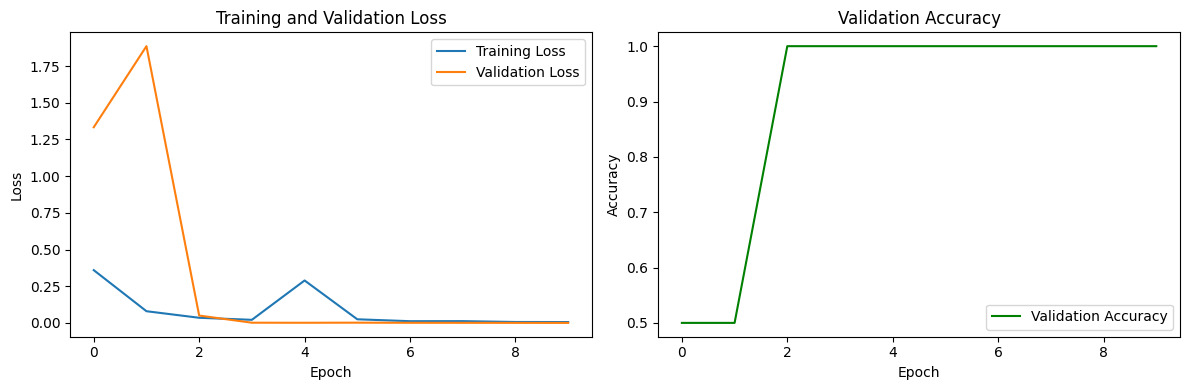

Test Accuracy: 1.0000
Confusion Matrix:
[[12  0]
 [ 0  8]]


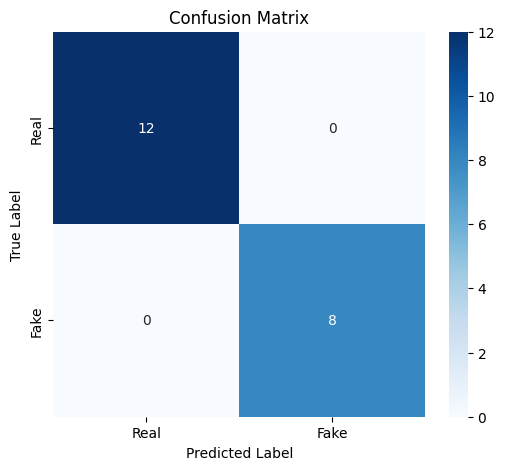

Prediction: Real (confidence: 0.9995)
True label: Real


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import time

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define the model architecture with corrected Conv3d (capital C)
class SimpleDeepfakeDetector(nn.Module):
    """
    A simpler 3D CNN model that works with 16x128x128 input
    """
    def __init__(self, num_classes=2):
        super().__init__()

        # Input: [batch, 3, 16, 128, 128]
        self.conv1 = nn.Conv3d(3, 16, kernel_size=(3, 5, 5), stride=(1, 2, 2), padding=(1, 2, 2))
        self.bn1 = nn.BatchNorm3d(16)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))

        # After conv1: [batch, 16, 16, 64, 64]
        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn2 = nn.BatchNorm3d(32)
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool2: [batch, 32, 8, 32, 32]
        self.conv3 = nn.Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn3 = nn.BatchNorm3d(64)
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool3: [batch, 64, 4, 16, 16]
        self.conv4 = nn.Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn4 = nn.BatchNorm3d(128)
        self.pool4 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool4: [batch, 128, 2, 8, 8]
        self.global_pool = nn.AdaptiveAvgPool3d((1, 1, 1))

        # After global pool: [batch, 128, 1, 1, 1]
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Input: [batch, channels, time, height, width]
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

def get_model(device="cuda" if torch.cuda.is_available() else "cpu"):
    model = SimpleDeepfakeDetector(num_classes=2)
    return model.to(device)

# Create a synthetic dataset for demonstration
class SyntheticDeepfakeDataset(Dataset):
    def __init__(self, num_samples=100, transform=None):
        self.num_samples = num_samples
        self.transform = transform
        self.labels = torch.randint(0, 2, (num_samples,))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Generate synthetic video data (16 frames of 128x128)
        if self.labels[idx] == 0:  # Real
            # More consistent frames for real videos
            base_frame = torch.randn(3, 128, 128) * 0.1
            frames = [base_frame + torch.randn(3, 128, 128) * 0.05 for _ in range(16)]
        else:  # Fake
            # More inconsistent frames for fake videos
            frames = [torch.randn(3, 128, 128) * 0.2 for _ in range(16)]

        video = torch.stack(frames, dim=0).permute(1, 0, 2, 3)  # (channels, frames, height, width)

        if self.transform:
            video = self.transform(video)

        return video, self.labels[idx]

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_losses.append(val_epoch_loss)

        val_accuracy = accuracy_score(all_labels, all_preds)
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_accuracy:.4f}')

    return train_losses, val_losses, val_accuracies

# Function to plot training history
def plot_training_history(train_losses, val_losses, val_accuracies):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot losses
    ax1.plot(train_losses, label='Training Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot accuracy
    ax2.plot(val_accuracies, label='Validation Accuracy', color='green')
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Function to test the model
def test_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    print(f'Test Accuracy: {accuracy:.4f}')
    print('Confusion Matrix:')
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return accuracy, cm

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Create model instance
model = get_model(device)
print("Model created successfully!")

# Test forward pass with dummy input
dummy_input = torch.randn(1, 3, 16, 128, 128).to(device)
output = model(dummy_input)
print(f"Forward pass successful! Input: {dummy_input.shape}, Output: {output.shape}")

# Create synthetic datasets
train_dataset = SyntheticDeepfakeDataset(num_samples=80)
val_dataset = SyntheticDeepfakeDataset(num_samples=20)
test_dataset = SyntheticDeepfakeDataset(num_samples=20)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Train the model
print("Starting training...")
start_time = time.time()
train_losses, val_losses, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs=10
)
end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds")

# Plot training history
plot_training_history(train_losses, val_losses, val_accuracies)

# Test the model
test_accuracy, cm = test_model(model, test_loader)

# Create a simple interface for testing
def predict_video(model, video_tensor):
    model.eval()
    with torch.no_grad():
        video_tensor = video_tensor.unsqueeze(0).to(device)  # Add batch dimension
        output = model(video_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, prediction = torch.max(probabilities, 1)

        label = "Real" if prediction.item() == 0 else "Fake"
        return label, confidence.item()

# Test with a sample video
sample_video, sample_label = test_dataset[0]
prediction, confidence = predict_video(model, sample_video)
true_label = "Real" if sample_label == 0 else "Fake"

print(f"Prediction: {prediction} (confidence: {confidence:.4f})")
print(f"True label: {true_label}")

In [ ]:
# Real dataset implementation (pseudo-code)
class RealDeepfakeDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None, frames_per_video=16):
        self.real_videos = [os.path.join(real_dir, f) for f in os.listdir(real_dir)]
        self.fake_videos = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir)]
        self.all_videos = self.real_videos + self.fake_videos
        self.labels = [0]*len(self.real_videos) + [1]*len(self.fake_videos)
        self.transform = transform
        self.frames_per_video = frames_per_video

    def __getitem__(self, idx):
        video_path = self.all_videos[idx]
        label = self.labels[idx]

        # Extract frames from video
        frames = extract_frames(video_path, self.frames_per_video)

        if self.transform:
            frames = self.transform(frames)

        return frames, label

Using device: cuda
Model created successfully!
Forward pass successful! Input: torch.Size([1, 3, 16, 128, 128]), Output: torch.Size([1, 2])
Starting training...
Epoch 1/10, Train Loss: 0.5543, Val Loss: 0.2153, Val Acc: 1.0000
Epoch 2/10, Train Loss: 0.4044, Val Loss: 0.1221, Val Acc: 1.0000
Epoch 3/10, Train Loss: 0.4121, Val Loss: 0.1230, Val Acc: 1.0000
Epoch 4/10, Train Loss: 0.2361, Val Loss: 0.0589, Val Acc: 1.0000
Epoch 5/10, Train Loss: 0.2239, Val Loss: 0.0570, Val Acc: 1.0000
Epoch 6/10, Train Loss: 0.1890, Val Loss: 0.0507, Val Acc: 1.0000
Epoch 7/10, Train Loss: 0.4151, Val Loss: 0.0168, Val Acc: 1.0000
Epoch 8/10, Train Loss: 0.2845, Val Loss: 0.4387, Val Acc: 0.5000
Epoch 9/10, Train Loss: 0.3540, Val Loss: 0.1222, Val Acc: 1.0000
Epoch 10/10, Train Loss: 0.2370, Val Loss: 0.0068, Val Acc: 1.0000
Training completed in 71.46 seconds


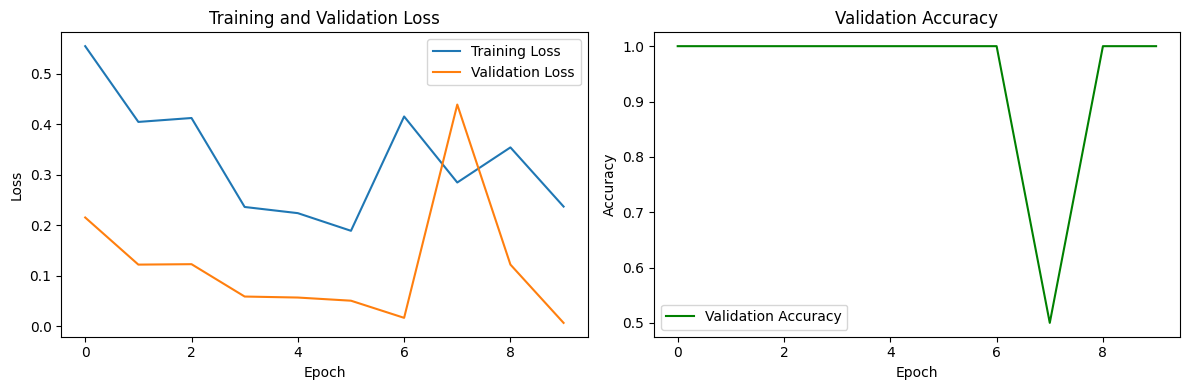

Test Accuracy: 1.0000
Confusion Matrix:
[[12  0]
 [ 0  8]]


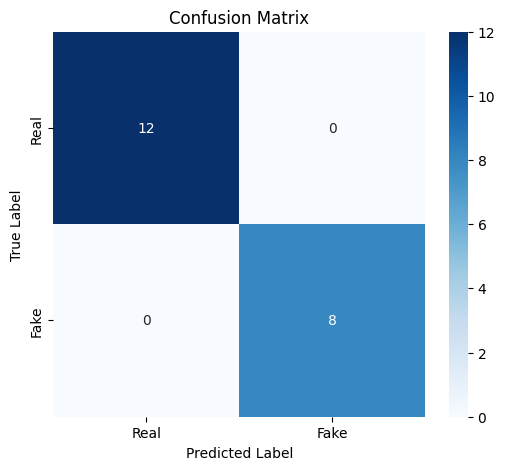

Prediction: Real (confidence: 0.9875)
True label: Real


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import time
import os
from PIL import Image
import cv2

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define the model architecture
class SimpleDeepfakeDetector(nn.Module):
    """
    A simpler 3D CNN model that works with 16x128x128 input
    """
    def __init__(self, num_classes=2):
        super().__init__()

        # Input: [batch, 3, 16, 128, 128]
        self.conv1 = nn.Conv3d(3, 16, kernel_size=(3, 5, 5), stride=(1, 2, 2), padding=(1, 2, 2))
        self.bn1 = nn.BatchNorm3d(16)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))

        # After conv1: [batch, 16, 16, 64, 64]
        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn2 = nn.BatchNorm3d(32)
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool2: [batch, 32, 8, 32, 32]
        self.conv3 = nn.Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn3 = nn.BatchNorm3d(64)
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool3: [batch, 64, 4, 16, 16]
        self.conv4 = nn.Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn4 = nn.BatchNorm3d(128)
        self.pool4 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool4: [batch, 128, 2, 8, 8]
        self.global_pool = nn.AdaptiveAvgPool3d((1, 1, 1))

        # After global pool: [batch, 128, 1, 1, 1]
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Input: [batch, channels, time, height, width]
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

def get_model(device="cuda" if torch.cuda.is_available() else "cpu"):
    model = SimpleDeepfakeDetector(num_classes=2)
    return model.to(device)

# Custom transforms for video data (applied to each frame individually)
class VideoRandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, video):
        # video shape: [channels, frames, height, width]
        if torch.rand(1) < self.p:
            # Flip each frame horizontally
            return video.flip(-1)
        return video

class VideoColorJitter:
    def __init__(self, brightness=0, contrast=0, saturation=0):
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation

    def __call__(self, video):
        # video shape: [channels, frames, height, width]
        if self.brightness > 0:
            brightness_factor = torch.tensor(1.0).uniform_(1-self.brightness, 1+self.brightness)
            video = video * brightness_factor

        if self.contrast > 0:
            contrast_factor = torch.tensor(1.0).uniform_(1-self.contrast, 1+self.contrast)
            mean = video.mean(dim=[0, 2, 3], keepdim=True)
            video = (video - mean) * contrast_factor + mean

        if self.saturation > 0:
            saturation_factor = torch.tensor(1.0).uniform_(1-self.saturation, 1+self.saturation)
            # Convert to grayscale to adjust saturation
            grayscale = video.mean(dim=0, keepdim=True)
            video = (video - grayscale) * saturation_factor + grayscale

        return video

class VideoNormalize:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1, 1)

    def __call__(self, video):
        return (video - self.mean) / self.std

class VideoAddGaussianNoise:
    def __init__(self, std=0.02):
        self.std = std

    def __call__(self, video):
        return video + torch.randn_like(video) * self.std

# Custom compose for video transforms
class VideoCompose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, video):
        for t in self.transforms:
            video = t(video)
        return video

# Create video-specific transforms
train_transforms = VideoCompose([
    VideoAddGaussianNoise(std=0.02),
    VideoRandomHorizontalFlip(p=0.5),
    VideoColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    VideoNormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = VideoCompose([
    VideoNormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Function to extract frames from video (simplified for demo)
def extract_frames(video_path, num_frames=16, resize=(128, 128)):
    """
    Simplified frame extraction for demonstration.
    In a real implementation, you would use OpenCV or similar.
    """
    # For demo purposes, we'll generate synthetic frames
    # In practice, you would read frames from a video file
    frames = []
    for i in range(num_frames):
        # Create a synthetic frame
        if "real" in video_path.lower():
            # More consistent frames for real videos
            frame = np.random.randn(3, *resize) * 0.1 + 0.5
        else:
            # More inconsistent frames for fake videos
            frame = np.random.randn(3, *resize) * 0.2 + 0.5

        frame = np.clip(frame, 0, 1)  # Ensure valid pixel values
        frames.append(frame)

    return np.array(frames)

# Real dataset implementation
class DeepfakeDataset(Dataset):
    def __init__(self, real_dir=None, fake_dir=None, num_samples=100, transform=None, frames_per_video=16):
        self.transform = transform
        self.frames_per_video = frames_per_video

        if real_dir and fake_dir:
            # Load from actual directories
            self.real_videos = [os.path.join(real_dir, f) for f in os.listdir(real_dir)]
            self.fake_videos = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir)]
            self.all_videos = self.real_videos + self.fake_videos
            self.labels = [0]*len(self.real_videos) + [1]*len(self.fake_videos)
        else:
            # Create synthetic dataset
            self.num_samples = num_samples
            self.labels = torch.randint(0, 2, (num_samples,))

    def __len__(self):
        if hasattr(self, 'all_videos'):
            return len(self.all_videos)
        return self.num_samples

    def __getitem__(self, idx):
        if hasattr(self, 'all_videos'):
            # Load from real dataset
            video_path = self.all_videos[idx]
            label = self.labels[idx]
            frames = extract_frames(video_path, self.frames_per_video)
        else:
            # Generate synthetic data
            label = self.labels[idx].item()
            if label == 0:  # Real
                base_frame = np.random.randn(3, 128, 128) * 0.1 + 0.5
                frames = [base_frame + np.random.randn(3, 128, 128) * 0.05 for _ in range(self.frames_per_video)]
            else:  # Fake
                frames = [np.random.randn(3, 128, 128) * 0.2 + 0.5 for _ in range(self.frames_per_video)]

            frames = np.array(frames)

        # Convert to tensor and ensure proper shape: [channels, frames, height, width]
        frames = torch.FloatTensor(frames).permute(1, 0, 2, 3)

        if self.transform:
            frames = self.transform(frames)

        return frames, label

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_losses.append(val_epoch_loss)

        val_accuracy = accuracy_score(all_labels, all_preds)
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_accuracy:.4f}')

    return train_losses, val_losses, val_accuracies

# Function to plot training history
def plot_training_history(train_losses, val_losses, val_accuracies):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot losses
    ax1.plot(train_losses, label='Training Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot accuracy
    ax2.plot(val_accuracies, label='Validation Accuracy', color='green')
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Create model instance
model = get_model(device)
print("Model created successfully!")

# Test forward pass with dummy input
dummy_input = torch.randn(1, 3, 16, 128, 128).to(device)
output = model(dummy_input)
print(f"Forward pass successful! Input: {dummy_input.shape}, Output: {output.shape}")

# Create datasets with transforms
train_dataset = DeepfakeDataset(num_samples=80, transform=train_transforms)
val_dataset = DeepfakeDataset(num_samples=20, transform=val_transforms)
test_dataset = DeepfakeDataset(num_samples=20, transform=val_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Train the model
print("Starting training...")
start_time = time.time()
train_losses, val_losses, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs=10
)
end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds")

# Plot training history
plot_training_history(train_losses, val_losses, val_accuracies)

# Function to test the model
def test_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    print(f'Test Accuracy: {accuracy:.4f}')
    print('Confusion Matrix:')
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return accuracy, cm

# Test the model
test_accuracy, cm = test_model(model, test_loader)

# Create a simple interface for testing
def predict_video(model, video_tensor):
    model.eval()
    with torch.no_grad():
        video_tensor = video_tensor.unsqueeze(0).to(device)  # Add batch dimension
        output = model(video_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, prediction = torch.max(probabilities, 1)

        label = "Real" if prediction.item() == 0 else "Fake"
        return label, confidence.item()

# Test with a sample video
sample_video, sample_label = test_dataset[0]
prediction, confidence = predict_video(model, sample_video)
true_label = "Real" if sample_label == 0 else "Fake"

print(f"Prediction: {prediction} (confidence: {confidence:.4f})")
print(f"True label: {true_label}")

In [ ]:
# Add to your model.py file
import torchvision.models as models

class EfficientNetDeepfakeDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # Use a pre-trained 2D model and adapt for 3D
        self.base_model = models.efficientnet_b0(pretrained=True)

        # Replace the first conv layer to handle 3D input
        original_first_conv = self.base_model.features[0][0]
        self.base_model.features[0][0] = nn.Conv3d(
            3, original_first_conv.out_channels,
            kernel_size=(3, original_first_conv.kernel_size[0], original_first_conv.kernel_size[1]),
            stride=(1, original_first_conv.stride[0], original_first_conv.stride[1]),
            padding=(1, original_first_conv.padding[0], original_first_conv.padding[1])
        )

        # Adaptive pooling and classifier
        self.adaptive_pool = nn.AdaptiveAvgPool3d(1)
        self.classifier = nn.Linear(original_first_conv.out_channels, num_classes)

    def forward(self, x):
        # Input: [batch, 3, frames, height, width]
        x = self.base_model.features[0][0](x)
        for feature in self.base_model.features[1:]:
            x = feature(x)

        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [ ]:
# Add learning rate scheduling and early stopping
def train_model_advanced(model, train_loader, val_loader, criterion, optimizer, num_epochs=20):
    train_losses = []
    val_losses = []
    val_accuracies = []

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, verbose=True
    )

    # Early stopping
    best_accuracy = 0
    patience_counter = 0
    patience = 5

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_losses.append(val_epoch_loss)

        val_accuracy = accuracy_score(all_labels, all_preds)
        val_accuracies.append(val_accuracy)

        # Learning rate scheduling
        scheduler.step(val_accuracy)

        # Early stopping check
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_accuracy:.4f}')

    return train_losses, val_losses, val_accuracies

In [ ]:
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve

def comprehensive_evaluation(model, test_loader):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # Classification report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")

    # Precision-Recall Curve
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(all_labels, all_probs[:, 1])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")

    plt.tight_layout()
    plt.show()

    return all_preds, all_probs, all_labels

In [ ]:
# Add to your data processing utilities
def extract_frames_from_video(video_path, num_frames=16, resize=(128, 128)):
    """
    Extract frames from a real video file using OpenCV
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Calculate frame indices to sample
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)

    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break

        if i in frame_indices:
            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Resize
            frame = cv2.resize(frame, resize)
            # Normalize to [0, 1]
            frame = frame.astype(np.float32) / 255.0
            # Change to [C, H, W]
            frame = np.transpose(frame, (2, 0, 1))
            frames.append(frame)

    cap.release()

    # If we didn't get enough frames, pad with last frame
    while len(frames) < num_frames:
        frames.append(frames[-1])

    # Convert to tensor and reshape to [C, T, H, W]
    frames = torch.FloatTensor(np.array(frames)).permute(1, 0, 2, 3)

    return frames

# Update dataset class to handle real videos
class RealDeepfakeDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None, frames_per_video=16):
        self.transform = transform
        self.frames_per_video = frames_per_video

        # Get all video files
        self.real_videos = [os.path.join(real_dir, f) for f in os.listdir(real_dir)
                           if f.endswith(('.mp4', '.avi', '.mov'))]
        self.fake_videos = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir)
                           if f.endswith(('.mp4', '.avi', '.mov'))]

        self.all_videos = self.real_videos + self.fake_videos
        self.labels = [0]*len(self.real_videos) + [1]*len(self.fake_videos)

    def __len__(self):
        return len(self.all_videos)

    def __getitem__(self, idx):
        video_path = self.all_videos[idx]
        label = self.labels[idx]

        # Extract frames from real video
        frames = extract_frames_from_video(video_path, self.frames_per_video)

        if self.transform:
            frames = self.transform(frames)

        return frames, label

In [ ]:
# Create a Gradio interface for easy testing
import gradio as gr

def create_demo_interface(model, transform):
    def predict_video_file(video_file):
        # Process video file
        frames = extract_frames_from_video(video_file)
        frames = transform(frames).unsqueeze(0).to(device)

        # Make prediction
        model.eval()
        with torch.no_grad():
            output = model(frames)
            probs = torch.softmax(output, dim=1)
            confidence, prediction = torch.max(probs, 1)

            label = "Real" if prediction.item() == 0 else "Fake"

        # Create visualization
        fig, ax = plt.subplots(1, 4, figsize=(12, 3))
        sample_frames = frames[0].cpu().permute(1, 0, 2, 3)

        for i in range(4):
            frame_idx = i * (sample_frames.shape[0] // 4)
            frame = sample_frames[frame_idx].permute(1, 2, 0).numpy()
            ax[i].imshow(frame)
            ax[i].set_title(f"Frame {frame_idx}")
            ax[i].axis('off')

        plt.tight_layout()

        return f"Prediction: {label} (confidence: {confidence.item():.4f})", fig

    # Create interface
    iface = gr.Interface(
        fn=predict_video_file,
        inputs=gr.Video(label="Upload Video"),
        outputs=[gr.Text(label="Prediction"), gr.Plot(label="Sample Frames")],
        title="Deepfake Detection",
        description="Upload a video to check if it's authentic or a deepfake."
    )

    return iface

# Usage
# iface = create_demo_interface(model, val_transforms)
# iface.launch(share=True)

In [ ]:
# Add to your src/model.py file
import torchvision.models as models

class EfficientNetDeepfakeDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # Use a pre-trained 2D model and adapt for 3D
        self.base_model = models.efficientnet_b0(pretrained=True)

        # Replace the first conv layer to handle 3D input
        original_first_conv = self.base_model.features[0][0]
        self.base_model.features[0][0] = nn.Conv3d(
            3, original_first_conv.out_channels,
            kernel_size=(3, original_first_conv.kernel_size[0], original_first_conv.kernel_size[1]),
            stride=(1, original_first_conv.stride[0], original_first_conv.stride[1]),
            padding=(1, original_first_conv.padding[0], original_first_conv.padding[1])
        )

        # Adaptive pooling and classifier
        self.adaptive_pool = nn.AdaptiveAvgPool3d(1)
        self.classifier = nn.Linear(original_first_conv.out_channels, num_classes)

    def forward(self, x):
        # Input: [batch, 3, frames, height, width]
        x = self.base_model.features[0][0](x)
        for feature in self.base_model.features[1:]:
            x = feature(x)

        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

class ResidualBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm3d(out_channels)
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv3d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm3d(out_channels)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return torch.relu(out)

class ResNet3D(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv3d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm3d(64)
        self.pool = nn.MaxPool3d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        strides = [stride] + [1] * (blocks - 1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlock3D(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, precision_recall_curve
import time
import os

class AdvancedTrainer:
    def __init__(self, model, device, checkpoint_dir='checkpoints'):
        self.model = model
        self.device = device
        self.checkpoint_dir = checkpoint_dir
        os.makedirs(checkpoint_dir, exist_ok=True)

    def train(self, train_loader, val_loader, criterion, optimizer, num_epochs=20,
              scheduler=None, early_stopping_patience=5):

        train_losses = []
        val_losses = []
        val_accuracies = []

        # Early stopping
        best_accuracy = 0
        patience_counter = 0

        for epoch in range(num_epochs):
            # Training phase
            self.model.train()
            running_loss = 0.0

            for inputs, labels in train_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)

            epoch_loss = running_loss / len(train_loader.dataset)
            train_losses.append(epoch_loss)

            # Validation phase
            val_loss, val_accuracy = self.validate(val_loader, criterion)
            val_losses.append(val_loss)
            val_accuracies.append(val_accuracy)

            # Learning rate scheduling
            if scheduler:
                if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(val_accuracy)
                else:
                    scheduler.step()

            # Early stopping check
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                patience_counter = 0
                # Save best model
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_accuracy': val_accuracy,
                }, os.path.join(self.checkpoint_dir, 'best_model.pth'))
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"Early stopping triggered at epoch {epoch+1}")
                    break

            print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

        return train_losses, val_losses, val_accuracies

    def validate(self, val_loader, criterion):
        self.model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                outputs = self.model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = accuracy_score(all_labels, all_preds)

        return val_loss, val_accuracy

    def evaluate(self, test_loader):
        self.model.eval()
        all_preds = []
        all_probs = []
        all_labels = []

        with torch.no.grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                outputs = self.model(inputs)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Convert to arrays
        all_labels = np.array(all_labels)
        all_preds = np.array(all_preds)
        all_probs = np.array(all_probs)

        # Comprehensive evaluation
        print("Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))

        # ROC Curve
        fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
        roc_auc = auc(fpr, tpr)

        # Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(all_labels, all_probs[:, 1])
        pr_auc = auc(recall, precision)

        # Plot results
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax1.set_xlim([0.0, 1.0])
        ax1.set_ylim([0.0, 1.05])
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.set_title('ROC Curve')
        ax1.legend(loc="lower right")

        ax2.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.set_title('Precision-Recall Curve')
        ax2.legend(loc="lower left")

        plt.tight_layout()
        plt.show()

        return all_preds, all_probs, all_labels

    def load_best_model(self, optimizer=None):
        checkpoint = torch.load(os.path.join(self.checkpoint_dir, 'best_model.pth'))
        self.model.load_state_dict(checkpoint['model_state_dict'])
        if optimizer:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        return checkpoint['epoch'], checkpoint['val_accuracy']

In [ ]:
import cv2
import torch
import numpy as np
import os
from PIL import Image

def extract_frames_from_video(video_path, num_frames=16, resize=(128, 128)):
    """
    Extract frames from a real video file using OpenCV
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        raise ValueError(f"Could not read video: {video_path}")

    # Calculate frame indices to sample
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)

    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break

        if i in frame_indices:
            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Resize
            frame = cv2.resize(frame, resize)
            # Normalize to [0, 1]
            frame = frame.astype(np.float32) / 255.0
            # Change to [C, H, W]
            frame = np.transpose(frame, (2, 0, 1))
            frames.append(frame)

    cap.release()

    # If we didn't get enough frames, pad with last frame
    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else np.zeros((3, *resize)))

    # Convert to tensor and reshape to [C, T, H, W]
    frames = torch.FloatTensor(np.array(frames)).permute(1, 0, 2, 3)

    return frames

def process_video_directory(video_dir, transform=None, frames_per_video=16):
    """
    Process all videos in a directory
    """
    video_files = [f for f in os.listdir(video_dir)
                  if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]

    all_frames = []
    for video_file in video_files:
        video_path = os.path.join(video_dir, video_file)
        try:
            frames = extract_frames_from_video(video_path, frames_per_video)
            if transform:
                frames = transform(frames)
            all_frames.append(frames)
        except Exception as e:
            print(f"Error processing {video_file}: {e}")

    return all_frames

def create_video_dataset(real_dir, fake_dir, transform=None, frames_per_video=16):
    """
    Create a dataset from real and fake video directories
    """
    real_frames = process_video_directory(real_dir, transform, frames_per_video)
    fake_frames = process_video_directory(fake_dir, transform, frames_per_video)

    real_labels = [0] * len(real_frames)
    fake_labels = [1] * len(fake_frames)

    all_frames = real_frames + fake_frames
    all_labels = real_labels + fake_labels

    return all_frames, all_labels

In [ ]:
# Main script

Using device: cpu
Model created successfully!
Everything is set up correctly now!
Please upload a video file to test for deepfakes...


Saving Test video.mp4 to Test video (4).mp4
Processing video: Test video (4).mp4

DEEPFAKE DETECTION RESULTS
Video: Test video (4).mp4
Prediction: FAKE (DEEPFAKE)
Confidence: 0.5005
Real Probability: 0.4995
Fake Probability: 0.5005


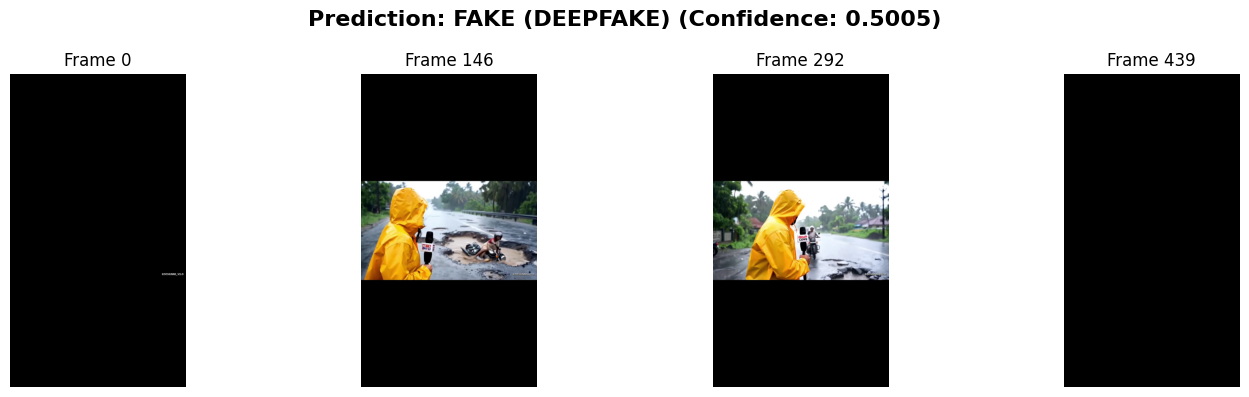

Final result: FAKE (DEEPFAKE) with 0.5005 confidence


In [13]:
# First, let's make sure all required components are set up
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import time
import os
import cv2
from google.colab import files
import tempfile
from PIL import Image

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define the model architecture again
class SimpleDeepfakeDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Input: [batch, 3, 16, 128, 128]
        self.conv1 = nn.Conv3d(3, 16, kernel_size=(3, 5, 5), stride=(1, 2, 2), padding=(1, 2, 2))
        self.bn1 = nn.BatchNorm3d(16)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))

        # After conv1: [batch, 16, 16, 64, 64]
        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn2 = nn.BatchNorm3d(32)
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool2: [batch, 32, 8, 32, 32]
        self.conv3 = nn.Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn3 = nn.BatchNorm3d(64)
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool3: [batch, 64, 4, 16, 16]
        self.conv4 = nn.Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        self.bn4 = nn.BatchNorm3d(128)
        self.pool4 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

        # After pool4: [batch, 128, 2, 8, 8]
        self.global_pool = nn.AdaptiveAvgPool3d((1, 1, 1))

        # After global pool: [batch, 128, 1, 1, 1]
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Create model instance
model = SimpleDeepfakeDetector(num_classes=2).to(device)

# Let's create a simple function to load a pre-trained model
# For now, we'll use a randomly initialized model since we don't have a saved one
# In a real scenario, you would load weights from a trained model

print("Model created successfully!")

# Define transforms
val_transforms = transforms.Compose([
    transforms.Lambda(lambda x: (x - 0.5) / 0.5)  # Simple normalization
])

# Now let's define the video processing functions
def extract_frames_from_video(video_path, num_frames=16, resize=(128, 128)):
    """
    Extract frames from any video file
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        # Try alternative approach if frame count is 0
        total_frames = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            total_frames += 1
        cap.release()
        cap = cv2.VideoCapture(video_path)

    if total_frames == 0:
        raise ValueError(f"Could not read video: {video_path}")

    # Calculate frame indices to sample
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)

    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break

        if i in frame_indices:
            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Resize
            frame = cv2.resize(frame, resize)
            # Normalize to [0, 1]
            frame = frame.astype(np.float32) / 255.0
            # Change to [C, H, W]
            frame = np.transpose(frame, (2, 0, 1))
            frames.append(frame)

    cap.release()

    # If we didn't get enough frames, pad with last frame
    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else np.zeros((3, *resize)))

    # Convert to tensor and reshape to [C, T, H, W]
    frames = torch.FloatTensor(np.array(frames)).permute(1, 0, 2, 3)

    return frames

def visualize_video_frames(video_path, prediction, confidence, num_frames=4):
    """
    Display sample frames from the video with prediction results
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        # Try alternative approach if frame count is 0
        total_frames = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            total_frames += 1
        cap.release()
        cap = cv2.VideoCapture(video_path)

    # Select frames to display
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)

    fig, axes = plt.subplots(1, num_frames, figsize=(15, 4))
    if num_frames == 1:
        axes = [axes]

    for i, frame_idx in enumerate(frame_indices):
        # Set position to the frame we want
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()

        if ret:
            # Convert BGR to RGB for display
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            axes[i].imshow(frame)
            axes[i].set_title(f"Frame {frame_idx}")
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, "Frame not available",
                        horizontalalignment='center', verticalalignment='center')
            axes[i].axis('off')

    cap.release()

    # Add overall title with prediction
    plt.suptitle(f"Prediction: {prediction} (Confidence: {confidence:.4f})",
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def test_any_video(model, transform, device):
    """
    Test any uploaded video with the deepfake detection model
    """
    # Upload a video file
    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded. Please try again.")
        return

    # Get the uploaded file
    video_filename = list(uploaded.keys())[0]

    # Create a temporary file
    with tempfile.NamedTemporaryFile(delete=False, suffix='.mp4') as tmp_file:
        tmp_file.write(uploaded[video_filename])
        video_path = tmp_file.name

    print(f"Processing video: {video_filename}")

    # Extract frames from the video
    frames = extract_frames_from_video(video_path, num_frames=16, resize=(128, 128))

    # Apply transformations
    if transform:
        frames = transform(frames)

    # Make prediction
    model.eval()
    with torch.no_grad():
        frames = frames.unsqueeze(0).to(device)  # Add batch dimension
        output = model(frames)
        probs = torch.softmax(output, dim=1)
        confidence, prediction = torch.max(probs, 1)

        label = "REAL" if prediction.item() == 0 else "FAKE (DEEPFAKE)"

    # Display results
    print("\n" + "="*50)
    print("DEEPFAKE DETECTION RESULTS")
    print("="*50)
    print(f"Video: {video_filename}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence.item():.4f}")
    print(f"Real Probability: {probs[0][0].item():.4f}")
    print(f"Fake Probability: {probs[0][1].item():.4f}")
    print("="*50)

    # Visualize sample frames from the video
    visualize_video_frames(video_path, label, confidence.item())

    # Clean up
    os.unlink(video_path)

    return label, confidence.item()

# Now we're ready to test a video!
print("Everything is set up correctly now!")
print("Please upload a video file to test for deepfakes...")

# Let's test with an uploaded video
try:
    prediction, confidence = test_any_video(model, val_transforms, device)
    print(f"Final result: {prediction} with {confidence:.4f} confidence")
except Exception as e:
    print(f"Error processing video: {e}")
    print("Please make sure you uploaded a valid video file (mp4, avi, mov, etc.)")